# Experiment 1 — QRS morphology replication (12 × 10 bins)

**Goal.** Reproduce and extend the QRS-morphology approach of Doste et al. (2022) and
Bocanegra-Pérez et al. (2024) for binary site-of-origin classification (LVOT = 0, RVOT = 1).

This notebook is a **single, sequential pipeline**. Each phase consumes the decision made
by the previous one:

```
0. Config & helpers      (binning, double-metric CV)
1. Load data + EDA
2. Representation         (12 leads × 10 temporal bins = 120 features)
3. Phase A — dataset selection      → best_dataset_combo
4. Phase B — lead selection         → best_lead_combo   (uses A)
5. Phase C — model selection        → best_model        (uses A + B)
6. Final model              → train once, evaluate ONCE on Teknon test
7. Interpretability         (feature importance / SHAP / lead × bin map)
```

**Methodological contract (read this before running).**

* Cross-validation folds are built over the **entire training pool**, never per dataset
  combination. Inside every fold we report **two** metrics:
  1. *Global* validation metrics (all samples in the fold).
  2. *Teknon-only* validation metrics (the Teknon samples that fell in the fold).
* The **final Teknon test set is sacred**: it is touched **once**, in §6, after every
  selection (datasets, leads, model) is already frozen. It is never used for any decision.
* The primary selection criterion is **balanced accuracy on Teknon-validation**, because
  the final held-out test comes from Teknon and the classes are imbalanced.


## 0. Imports, config & helpers

In [4]:
import os
# If running locally, adapt this so saved CSV/PNG artifacts land next to the data:
# os.chdir(r"c:\Users\jaime\Downloads\corrected_split_pool\corrected_split_pool")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from pathlib import Path
from itertools import combinations

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              GradientBoostingClassifier)
from sklearn.neural_network import MLPClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve)

# Optional extras (the notebook still runs without them)
try:
    from xgboost import XGBClassifier
    XGB_AVAILABLE = True
except Exception as e:
    XGB_AVAILABLE = False
    print(f"XGBoost not available ({e!s}); it will be skipped in Phase C.")

try:
    import shap
    SHAP_AVAILABLE = True
except Exception as e:
    SHAP_AVAILABLE = False
    print(f"SHAP not available ({e!s}); the SHAP block will be skipped.")

# ---------- Global config ----------
RANDOM_STATE = 42
N_FOLDS = 5
N_BINS = 10

LEAD_NAMES = ["I", "II", "III", "aVR", "aVL", "aVF",
              "V1", "V2", "V3", "V4", "V5", "V6"]
CLASS_NAMES = ["LVOT", "RVOT"]      # 0 = LVOT, 1 = RVOT

np.random.seed(RANDOM_STATE)

# ONE splitter object, reused across every phase so the folds are identical everywhere.
SKF = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)


def find_file(filename):
    """Locate a data file in the current dir or its parent."""
    for p in (Path(".") / filename, Path("..") / filename):
        if p.exists():
            return str(p)
    raise FileNotFoundError(
        f"Could not find {filename}. Put it next to the notebook or in the parent folder."
    )

print("Config loaded. N_FOLDS =", N_FOLDS, "| N_BINS =", N_BINS,
      "| XGB:", XGB_AVAILABLE, "| SHAP:", SHAP_AVAILABLE)

Config loaded. N_FOLDS = 5 | N_BINS = 10 | XGB: True | SHAP: True


### 0.1 The double-metric cross-validation helper

This is the heart of the whole notebook. It is written **once** here and reused unchanged
by Phases A, B and C, which guarantees that every selection decision is made under exactly
the same protocol.

Key design points:

* `dataset_mask` lets a phase **restrict the training portion** of each fold to a subset of
  datasets (Phase A), while the **validation portion is always the full fold** — so we can
  always measure transfer to Teknon.
* `lead_idx` lets a phase **restrict which leads** (hence which of the 120 columns) are used
  (Phase B).
* For every fold we compute global metrics and, separately, metrics on the Teknon samples
  inside that fold.


In [5]:
def metrics_block(y_true, y_pred, y_score):
    """Return the four headline metrics; AUC guarded for single-class slices."""
    out = {
        "accuracy":          accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1":          f1_score(y_true, y_pred, average="macro"),
    }
    # ROC-AUC needs both classes present
    if len(np.unique(y_true)) == 2:
        out["roc_auc"] = roc_auc_score(y_true, y_score)
    else:
        out["roc_auc"] = np.nan
    return out


def _scores_from(est, X):
    """Probability/score for the positive class, whatever the estimator exposes."""
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    if hasattr(est, "decision_function"):
        return est.decision_function(X)
    return est.predict(X)


def cv_double_metric(model, X, y, is_teknon,
                     dataset_train_mask=None, lead_cols=None,
                     splitter=SKF):
    """Stratified CV that reports GLOBAL and TEKNON-ONLY validation metrics per fold.

    Parameters
    ----------
    model         : an unfitted sklearn estimator (will be cloned per fold)
    X             : (n_samples, 120) binned feature matrix (full lead set)
    y             : (n_samples,) labels
    is_teknon     : (n_samples,) boolean — True for Teknon-sourced rows
    dataset_train_mask : optional (n_samples,) boolean. If given, the TRAINING part of each
                         fold is filtered to rows where this is True. Validation is NEVER
                         filtered. Use this for Phase A (dataset selection).
    lead_cols     : optional list of column indices (into the 120 features) to keep.
                    Use this for Phase B (lead selection).
    Returns
    -------
    DataFrame with one row per fold, columns prefixed `g_` (global) and `t_` (Teknon-only).
    """
    rows = []
    for fold, (tr, va) in enumerate(splitter.split(X, y)):
        # Restrict the training rows to the selected datasets (validation stays whole)
        if dataset_train_mask is not None:
            tr = tr[dataset_train_mask[tr]]
        Xtr, ytr = X[tr], y[tr]
        Xva, yva = X[va], y[va]
        if lead_cols is not None:
            Xtr, Xva = Xtr[:, lead_cols], Xva[:, lead_cols]

        est = clone(model).fit(Xtr, ytr)
        pred = est.predict(Xva)
        score = _scores_from(est, Xva)

        g = metrics_block(yva, pred, score)               # global
        tek = is_teknon[va]
        if tek.sum() > 0:
            tk = metrics_block(yva[tek], pred[tek], score[tek])
        else:
            tk = {k: np.nan for k in g}                    # no Teknon in this fold

        rows.append({
            "fold": fold,
            "n_train": len(tr), "n_val": len(va), "n_val_teknon": int(tek.sum()),
            **{f"g_{k}": v for k, v in g.items()},
            **{f"t_{k}": v for k, v in tk.items()},
        })
    return pd.DataFrame(rows)


def summarise(folds_df, label):
    """Collapse per-fold metrics to mean ± std, keeping global and Teknon columns."""
    cols = [c for c in folds_df.columns if c.startswith(("g_", "t_"))]
    agg = folds_df[cols].agg(["mean", "std"])
    row = {"config": label}
    for c in cols:
        row[f"{c}_mean"] = agg.loc["mean", c]
        row[f"{c}_std"]  = agg.loc["std",  c]
    return row

print("Double-metric CV helper defined.")

Double-metric CV helper defined.


## 1. Load data & quick EDA

In [6]:
X_train_pool = np.load(find_file("X_train_pool_binary_corrected_clean.npy"))
y_train_pool = np.load(find_file("y_train_pool_binary_corrected_clean.npy")).astype(int)
X_test = np.load(find_file("X_teknon_final_test_binary_corrected_clean.npy"))
y_test = np.load(find_file("y_teknon_final_test_binary_corrected_clean.npy")).astype(int)

info_train = pd.read_csv(find_file("info_train_pool_binary_corrected_clean.csv"))
info_test  = pd.read_csv(find_file("info_teknon_final_test_binary_corrected_clean.csv"))

# Source-dataset string per training row, and a Teknon boolean mask
dataset_train = info_train["dataset"].astype(str).values
IS_TEKNON = (dataset_train == "Teknon")

print("X_train_pool:", X_train_pool.shape, "| X_test:", X_test.shape)
print("Train class balance:", dict(zip(*np.unique(y_train_pool, return_counts=True))))
print("Test  class balance:", dict(zip(*np.unique(y_test, return_counts=True))))
print("\\nTraining pool by source dataset:")
print(info_train["dataset"].value_counts())
print(f"\\nTeknon rows in pool: {IS_TEKNON.sum()}  "
      f"(class balance: {dict(zip(*np.unique(y_train_pool[IS_TEKNON], return_counts=True)))})")

X_train_pool: (3009, 12, 200) | X_test: (36, 12, 200)
Train class balance: {0: 1613, 1: 1396}
Test  class balance: {0: 18, 1: 18}
\nTraining pool by source dataset:
dataset
Sims        2496
Database     333
Teknon       137
CARTO         43
Name: count, dtype: int64
\nTeknon rows in pool: 137  (class balance: {0: 54, 1: 83})


**Sanity note.** The test set is 100% Teknon. The training pool is dominated by simulated
signals (`Sims`). Phase A is precisely designed to find out whether, and how much, the
simulated and non-Teknon real data help generalisation to Teknon — measured by the
Teknon-only validation metric.

## 2. Representation — 12 leads × 10 temporal bins

In [7]:
def create_binned_qrs_features(X, lead_names=LEAD_NAMES, n_bins=N_BINS, aggregation="mean"):
    """(n, 12, 200) -> (n, 12*n_bins). Each feature = mean of one lead in one 10% window.

    Follows Doste (2022) / Bocanegra (2024): each QRS is summarised to 10 values per lead.
    """
    n_samples, n_leads, n_timepoints = X.shape
    edges = np.linspace(0, n_timepoints, n_bins + 1, dtype=int)
    pct = np.linspace(0, 100, n_bins + 1, dtype=int)
    Xb = np.zeros((n_samples, n_leads * n_bins), dtype=np.float32)
    names = []
    for li, lead in enumerate(lead_names):
        for bi in range(n_bins):
            seg = X[:, li, edges[bi]:edges[bi + 1]]
            Xb[:, li * n_bins + bi] = seg.mean(axis=1) if aggregation == "mean" \
                                       else np.max(np.abs(seg), axis=1)
            names.append(f"{lead}_{pct[bi]}_{pct[bi+1]}")
    return Xb, names


X_train_binned, FEATURE_NAMES = create_binned_qrs_features(X_train_pool)
X_test_binned,  _             = create_binned_qrs_features(X_test)

# Map each lead to its 10 column indices in the 120-feature vector (used by Phase B)
LEAD_TO_COLS = {lead: list(range(i * N_BINS, (i + 1) * N_BINS))
                for i, lead in enumerate(LEAD_NAMES)}

print("Binned train:", X_train_binned.shape, "| Binned test:", X_test_binned.shape)
print("Example feature names:", FEATURE_NAMES[:3], "...", FEATURE_NAMES[-3:])

Binned train: (3009, 120) | Binned test: (36, 120)
Example feature names: ['I_0_10', 'I_10_20', 'I_20_30'] ... ['V6_70_80', 'V6_80_90', 'V6_90_100']


## 3. Phase A — dataset selection

We compare which **training data sources** help most. The validation portion of each fold is
always the full fold, so the Teknon-only metric is always computable. The training portion is
filtered to the datasets of each combination.

Combinations (edit freely):

| Tag | Datasets in training |
|-----|----------------------|
| A | Sims only |
| B | Real non-Teknon (CARTO + Database) |
| C | Teknon only |
| D | Sims + CARTO + Database |
| E | CARTO + Database + Teknon |
| F | All (Sims + CARTO + Database + Teknon) |

**Decision rule:** highest **Teknon-validation balanced accuracy** (`t_balanced_accuracy`),
breaking ties with global balanced accuracy.

In [8]:
DATASET_COMBOS = {
    "A_Sims_only":            ["Sims"],
    "B_real_nonTeknon":       ["CARTO", "Database"],
    "C_Teknon_only":          ["Teknon"],
    "D_Sims_CARTO_Database":  ["Sims", "CARTO", "Database"],
    "E_realAll_Teknon":       ["CARTO", "Database", "Teknon"],
    "F_all":                  ["Sims", "CARTO", "Database", "Teknon"],
}

# A fixed reference model for Phases A & B so the comparison isolates the data/lead effect,
# not the model. RandomForest is a strong, low-variance default; you can switch it.
REF_MODEL = RandomForestClassifier(
    n_estimators=400, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1)

phaseA_rows = []
t0 = time.time()
for tag, ds_list in DATASET_COMBOS.items():
    train_mask = np.isin(dataset_train, ds_list)
    folds = cv_double_metric(REF_MODEL, X_train_binned, y_train_pool, IS_TEKNON,
                             dataset_train_mask=train_mask)
    phaseA_rows.append(summarise(folds, tag))
    print(f"  {tag:24s} | global bal_acc = {folds['g_balanced_accuracy'].mean():.3f}"
          f" | Teknon bal_acc = {folds['t_balanced_accuracy'].mean():.3f}"
          f" (n_train≈{int(train_mask.sum())})", flush=True)

phaseA = (pd.DataFrame(phaseA_rows)
          .sort_values("t_balanced_accuracy_mean", ascending=False)
          .reset_index(drop=True))
phaseA.to_csv("exp1_phaseA_dataset_selection.csv", index=False)
print(f"\\nPhase A done in {time.time()-t0:.0f}s.")
phaseA[["config", "t_balanced_accuracy_mean", "t_balanced_accuracy_std",
        "g_balanced_accuracy_mean", "t_roc_auc_mean"]].round(3)

  A_Sims_only              | global bal_acc = 0.907 | Teknon bal_acc = 0.575 (n_train≈2496)
  B_real_nonTeknon         | global bal_acc = 0.570 | Teknon bal_acc = 0.725 (n_train≈376)
  C_Teknon_only            | global bal_acc = 0.555 | Teknon bal_acc = 0.694 (n_train≈137)
  D_Sims_CARTO_Database    | global bal_acc = 0.972 | Teknon bal_acc = 0.743 (n_train≈2872)
  E_realAll_Teknon         | global bal_acc = 0.559 | Teknon bal_acc = 0.701 (n_train≈513)
  F_all                    | global bal_acc = 0.972 | Teknon bal_acc = 0.697 (n_train≈3009)
\nPhase A done in 136s.


,config,t_balanced_accuracy_mean,t_balanced_accuracy_std,g_balanced_accuracy_mean,t_roc_auc_mean
0,D_Sims_CARTO_Database,0.743,0.067,0.972,0.821
1,B_real_nonTeknon,0.725,0.048,0.570,0.816
2,E_realAll_Teknon,0.701,0.056,0.559,0.821
3,F_all,0.697,0.059,0.972,0.811
4,C_Teknon_only,0.694,0.102,0.555,0.798
5,A_Sims_only,0.575,0.076,0.907,0.633


In [9]:
# ---- Freeze the winning dataset combination ----
best_dataset_combo = phaseA.iloc[0]["config"]
BEST_DATASETS = DATASET_COMBOS[best_dataset_combo]
BEST_DATASET_MASK = np.isin(dataset_train, BEST_DATASETS)
print(f"Best dataset combo (by Teknon bal_acc): {best_dataset_combo} -> {BEST_DATASETS}")
print(f"Training rows available with this combo: {BEST_DATASET_MASK.sum()}")

Best dataset combo (by Teknon bal_acc): D_Sims_CARTO_Database -> ['Sims', 'CARTO', 'Database']
Training rows available with this combo: 2872


## 4. Phase B — lead selection

With the dataset combination frozen, we ask which **leads** carry the signal. We restrict the
feature columns to the bins of the chosen leads and rerun the same double-metric CV.

Clinically motivated subsets (Doste found V2 then V3 most informative). You can expand this to
the full 4095-combination search if you have time, but these are the defensible candidates.

In [10]:
LEAD_SUBSETS = {
    "all_12":          LEAD_NAMES,
    "precordial_V1_V6":["V1", "V2", "V3", "V4", "V5", "V6"],
    "V1_V4":           ["V1", "V2", "V3", "V4"],
    "V2_V3_V4":        ["V2", "V3", "V4"],
    "V2_V3":           ["V2", "V3"],
    "V2_only":         ["V2"],
    "limb_only":       ["I", "II", "III", "aVR", "aVL", "aVF"],
}

def cols_for_leads(lead_list):
    cols = []
    for ld in lead_list:
        cols.extend(LEAD_TO_COLS[ld])
    return sorted(cols)

phaseB_rows = []
t0 = time.time()
for tag, leads in LEAD_SUBSETS.items():
    cols = cols_for_leads(leads)
    folds = cv_double_metric(REF_MODEL, X_train_binned, y_train_pool, IS_TEKNON,
                             dataset_train_mask=BEST_DATASET_MASK, lead_cols=cols)
    row = summarise(folds, tag)
    row["n_leads"] = len(leads); row["n_features"] = len(cols)
    phaseB_rows.append(row)
    print(f"  {tag:18s} ({len(leads):2d} leads) | global = {folds['g_balanced_accuracy'].mean():.3f}"
          f" | Teknon = {folds['t_balanced_accuracy'].mean():.3f}", flush=True)

phaseB = (pd.DataFrame(phaseB_rows)
          .sort_values("t_balanced_accuracy_mean", ascending=False)
          .reset_index(drop=True))
phaseB.to_csv("exp1_phaseB_lead_selection.csv", index=False)
print(f"\\nPhase B done in {time.time()-t0:.0f}s.")
phaseB[["config", "n_leads", "t_balanced_accuracy_mean",
        "g_balanced_accuracy_mean", "t_roc_auc_mean"]].round(3)

  all_12             (12 leads) | global = 0.972 | Teknon = 0.743
  precordial_V1_V6   ( 6 leads) | global = 0.962 | Teknon = 0.695
  V1_V4              ( 4 leads) | global = 0.951 | Teknon = 0.703
  V2_V3_V4           ( 3 leads) | global = 0.944 | Teknon = 0.698
  V2_V3              ( 2 leads) | global = 0.919 | Teknon = 0.684
  V2_only            ( 1 leads) | global = 0.899 | Teknon = 0.702
  limb_only          ( 6 leads) | global = 0.958 | Teknon = 0.602
\nPhase B done in 177s.


,config,n_leads,t_balanced_accuracy_mean,g_balanced_accuracy_mean,t_roc_auc_mean
0,all_12,12,0.743,0.972,0.821
1,V1_V4,4,0.703,0.951,0.761
2,V2_only,1,0.702,0.899,0.739
3,V2_V3_V4,3,0.698,0.944,0.768
4,precordial_V1_V6,6,0.695,0.962,0.801
5,V2_V3,2,0.684,0.919,0.739
6,limb_only,6,0.602,0.958,0.697


In [11]:
# ---- Freeze the winning lead subset ----
best_lead_combo = phaseB.iloc[0]["config"]
BEST_LEADS = LEAD_SUBSETS[best_lead_combo]
BEST_COLS = cols_for_leads(BEST_LEADS)
print(f"Best lead combo (by Teknon bal_acc): {best_lead_combo} -> {BEST_LEADS}")
print(f"Feature columns kept: {len(BEST_COLS)}")

Best lead combo (by Teknon bal_acc): all_12 -> ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Feature columns kept: 120


## 5. Phase C — model selection

Datasets and leads are now frozen. We compare classical models (Bocanegra's zoo): SVM, Random
Forest, Extra Trees, MLP, XGBoost. Same double-metric CV, same folds.

**Primary criterion:** Teknon-validation balanced accuracy.

In [12]:
def build_models(random_state=RANDOM_STATE):
    models = {}
    models["SVM"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", CalibratedClassifierCV(
            estimator=LinearSVC(class_weight="balanced", max_iter=5000,
                                random_state=random_state), cv=3)),
    ])
    models["RandomForest"] = RandomForestClassifier(
        n_estimators=500, class_weight="balanced", random_state=random_state, n_jobs=-1)
    models["ExtraTrees"] = ExtraTreesClassifier(
        n_estimators=500, class_weight="balanced", random_state=random_state, n_jobs=-1)
    models["MLP"] = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=2000,
                              early_stopping=True, random_state=random_state)),
    ])
    if XGB_AVAILABLE:
        models["XGBoost"] = XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.9, colsample_bytree=0.9, eval_metric="logloss",
            random_state=random_state, n_jobs=-1)
    return models


phaseC_rows = []
t0 = time.time()
for name, m in build_models().items():
    folds = cv_double_metric(m, X_train_binned, y_train_pool, IS_TEKNON,
                             dataset_train_mask=BEST_DATASET_MASK, lead_cols=BEST_COLS)
    phaseC_rows.append(summarise(folds, name))
    print(f"  {name:14s} | global = {folds['g_balanced_accuracy'].mean():.3f}"
          f" | Teknon = {folds['t_balanced_accuracy'].mean():.3f}"
          f" ± {folds['t_balanced_accuracy'].std():.3f}", flush=True)

phaseC = (pd.DataFrame(phaseC_rows)
          .sort_values("t_balanced_accuracy_mean", ascending=False)
          .reset_index(drop=True))
phaseC.to_csv("exp1_phaseC_model_selection.csv", index=False)
print(f"\\nPhase C done in {time.time()-t0:.0f}s.")
phaseC[["config", "t_balanced_accuracy_mean", "t_balanced_accuracy_std",
        "g_balanced_accuracy_mean", "t_roc_auc_mean"]].round(3)

  SVM            | global = 0.952 | Teknon = 0.635 ± 0.148
  RandomForest   | global = 0.972 | Teknon = 0.736 ± 0.065
  ExtraTrees     | global = 0.972 | Teknon = 0.718 ± 0.051
  MLP            | global = 0.966 | Teknon = 0.706 ± 0.046
  XGBoost        | global = 0.973 | Teknon = 0.755 ± 0.082
\nPhase C done in 84s.


,config,t_balanced_accuracy_mean,t_balanced_accuracy_std,g_balanced_accuracy_mean,t_roc_auc_mean
0,XGBoost,0.755,0.082,0.973,0.754
1,RandomForest,0.736,0.065,0.972,0.822
2,ExtraTrees,0.718,0.051,0.972,0.819
3,MLP,0.706,0.046,0.966,0.703
4,SVM,0.635,0.148,0.952,0.682


In [13]:
# ---- Freeze the winning model ----
best_model_name = phaseC.iloc[0]["config"]
print(f"Best model (by Teknon bal_acc): {best_model_name}")
print("\\n>>> Frozen configuration for the final model:")
print(f"    datasets = {best_dataset_combo} {BEST_DATASETS}")
print(f"    leads    = {best_lead_combo} {BEST_LEADS}")
print(f"    model    = {best_model_name}")

Best model (by Teknon bal_acc): XGBoost
\n>>> Frozen configuration for the final model:
    datasets = D_Sims_CARTO_Database ['Sims', 'CARTO', 'Database']
    leads    = all_12 ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
    model    = XGBoost


## 6. Final model — evaluate ONCE on the Teknon test

Everything is frozen. We now train the chosen model on all permitted training rows (the chosen
dataset combination, the chosen leads) and evaluate **exactly once** on the held-out 36-patient
Teknon test. **No decision is made after this point.**

In [14]:
# Assemble the final training matrix (chosen datasets + chosen leads)
final_train_rows = BEST_DATASET_MASK
X_final_train = X_train_binned[final_train_rows][:, BEST_COLS]
y_final_train = y_train_pool[final_train_rows]
X_final_test  = X_test_binned[:, BEST_COLS]

print(f"Final training matrix: {X_final_train.shape}  "
      f"(class balance {dict(zip(*np.unique(y_final_train, return_counts=True)))})")
print(f"Final test matrix    : {X_final_test.shape}")

final_model = clone(build_models()[best_model_name]).fit(X_final_train, y_final_train)

y_pred = final_model.predict(X_final_test)
y_score = _scores_from(final_model, X_final_test)

final_metrics = metrics_block(y_test, y_pred, y_score)
final_metrics["weighted_f1"] = f1_score(y_test, y_pred, average="weighted")
pd.DataFrame([{"model": best_model_name, **final_metrics}]).to_csv(
    "exp1_final_test_results.csv", index=False)

print("\\n=== FINAL Teknon test results ===")
for k, v in final_metrics.items():
    print(f"  {k:20s}: {v:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

Final training matrix: (2872, 120)  (class balance {0: 1559, 1: 1313})
Final test matrix    : (36, 120)
\n=== FINAL Teknon test results ===
  accuracy            : 0.778
  balanced_accuracy   : 0.778
  macro_f1            : 0.775
  roc_auc             : 0.818
  weighted_f1         : 0.775

              precision    recall  f1-score   support

        LVOT       0.86      0.67      0.75        18
        RVOT       0.73      0.89      0.80        18

    accuracy                           0.78        36
   macro avg       0.79      0.78      0.77        36
weighted avg       0.79      0.78      0.77        36



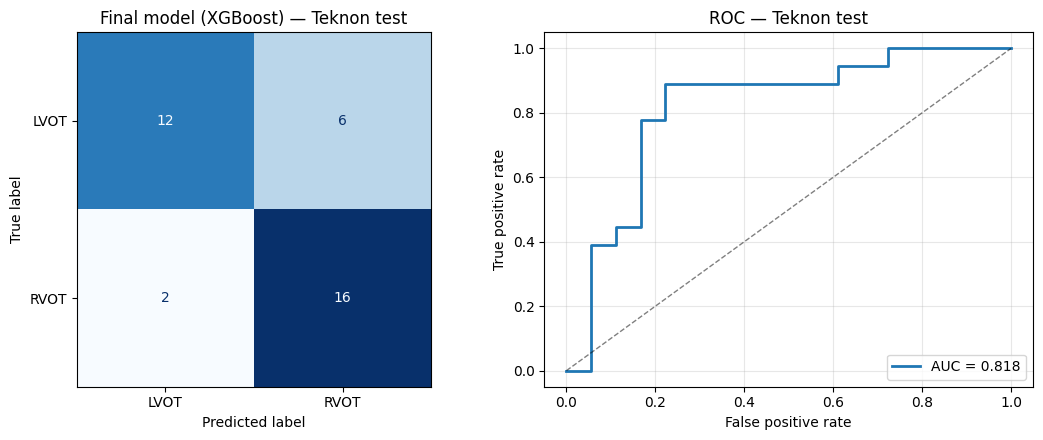

In [15]:
# Confusion matrix + ROC
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES).plot(
    ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title(f"Final model ({best_model_name}) — Teknon test")

if len(np.unique(y_test)) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    axes[1].plot(fpr, tpr, lw=2, label=f"AUC = {final_metrics['roc_auc']:.3f}")
    axes[1].plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
    axes[1].set_title("ROC — Teknon test"); axes[1].legend(loc="lower right")
    axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_exp1_final_confusion_roc.png", dpi=150, bbox_inches="tight")
plt.show()

### 6.1 Bootstrap confidence interval (because n = 36 is small)

A single patient flips accuracy by ~2.8 points, so a point estimate is misleading. We
bootstrap the 36 test predictions to put an interval around balanced accuracy.

In [16]:
rng = np.random.RandomState(RANDOM_STATE)
boot = []
n = len(y_test)
for _ in range(2000):
    idx = rng.randint(0, n, n)
    if len(np.unique(y_test[idx])) < 2:
        continue
    boot.append(balanced_accuracy_score(y_test[idx], y_pred[idx]))
boot = np.array(boot)
lo, hi = np.percentile(boot, [2.5, 97.5])
print(f"Balanced accuracy: {final_metrics['balanced_accuracy']:.3f} "
      f"(95% bootstrap CI: {lo:.3f}–{hi:.3f})")

Balanced accuracy: 0.778 (95% bootstrap CI: 0.631–0.910)


## 7. Interpretability

We explain the **final model** three ways, all on the chosen leads/features:

* per-feature importance (native for trees, permutation otherwise),
* aggregated per lead and per time-bin,
* a lead × bin heatmap,
* SHAP beeswarm if available and the model is tree-based.

The goal is to recover the Bocanegra finding: precordial leads (V2–V4) around the R/S
transition (≈60–70%) drive the decision.

In [17]:
SELECTED_FEATURE_NAMES = [FEATURE_NAMES[c] for c in BEST_COLS]

def get_importance(model, X, y, names, random_state=RANDOM_STATE):
    """Native importance for trees/XGB; permutation importance otherwise."""
    base = model.steps[-1][1] if isinstance(model, Pipeline) else model
    if hasattr(base, "feature_importances_"):
        return np.asarray(base.feature_importances_), "native"
    r = permutation_importance(model, X, y, n_repeats=20,
                               random_state=random_state, n_jobs=-1,
                               scoring="balanced_accuracy")
    return np.clip(r.importances_mean, 0, None), "permutation"

importance, imp_kind = get_importance(final_model, X_final_test, y_test, SELECTED_FEATURE_NAMES)
imp_df = (pd.DataFrame({"feature": SELECTED_FEATURE_NAMES, "importance": importance})
          .sort_values("importance", ascending=False).reset_index(drop=True))
print(f"Importance type: {imp_kind}")
imp_df.head(15)

Importance type: native


,feature,importance
0,V3_30_40,0.112194
1,V2_90_100,0.088482
2,V3_20_30,0.059725
3,V6_90_100,0.040072
4,aVF_60_70,0.035713
5,II_60_70,0.034860
6,I_10_20,0.033259
7,V6_10_20,0.030160
8,V5_60_70,0.027934
9,V3_60_70,0.021496


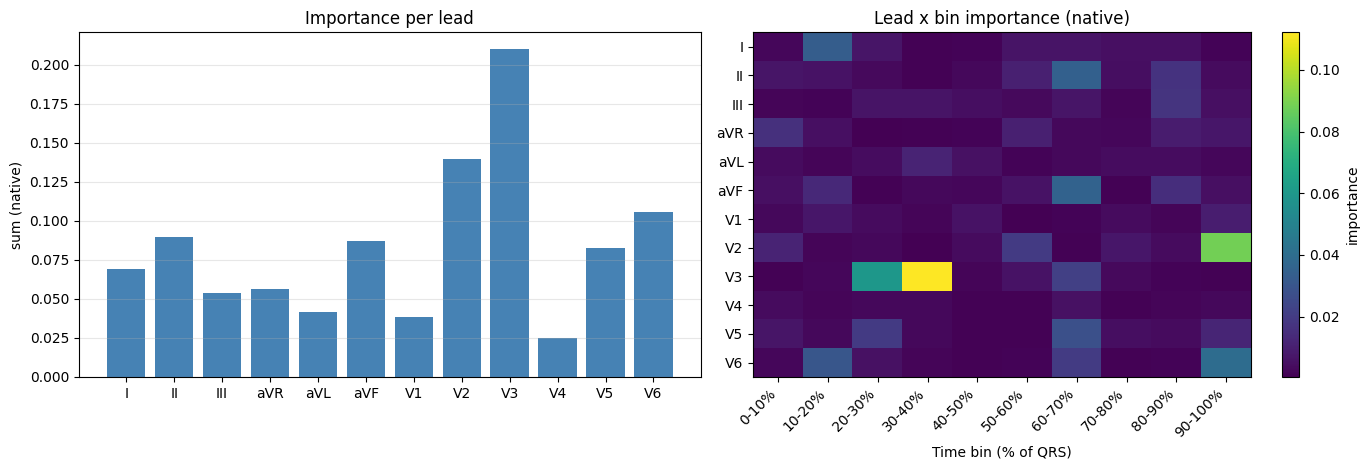

In [18]:
# Aggregate to a lead x bin matrix (only the leads we actually used)
used_leads = [ld for ld in LEAD_NAMES if ld in BEST_LEADS]
imp_matrix = np.full((len(used_leads), N_BINS), np.nan)
for fi, fname in enumerate(SELECTED_FEATURE_NAMES):
    lead = fname.rsplit("_", 2)[0]
    pct_lo = int(fname.rsplit("_", 2)[1])
    bin_idx = pct_lo // 10
    imp_matrix[used_leads.index(lead), bin_idx] = importance[fi]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

# (a) per-lead and per-bin bars
lead_imp = np.nansum(imp_matrix, axis=1)
bin_imp = np.nansum(imp_matrix, axis=0)
axes[0].bar(used_leads, lead_imp, color="steelblue")
axes[0].set_title("Importance per lead"); axes[0].set_ylabel(f"sum ({imp_kind})")
axes[0].grid(axis="y", alpha=0.3)

# (b) lead x bin heatmap
im = axes[1].imshow(imp_matrix, aspect="auto", cmap="viridis")
axes[1].set_yticks(range(len(used_leads))); axes[1].set_yticklabels(used_leads)
axes[1].set_xticks(range(N_BINS))
axes[1].set_xticklabels([f"{i*10}-{(i+1)*10}%" for i in range(N_BINS)],
                        rotation=45, ha="right")
axes[1].set_xlabel("Time bin (% of QRS)")
axes[1].set_title(f"Lead x bin importance ({imp_kind})")
fig.colorbar(im, ax=axes[1], label="importance")
plt.tight_layout()
plt.savefig("fig_exp1_importance.png", dpi=150, bbox_inches="tight")
plt.show()

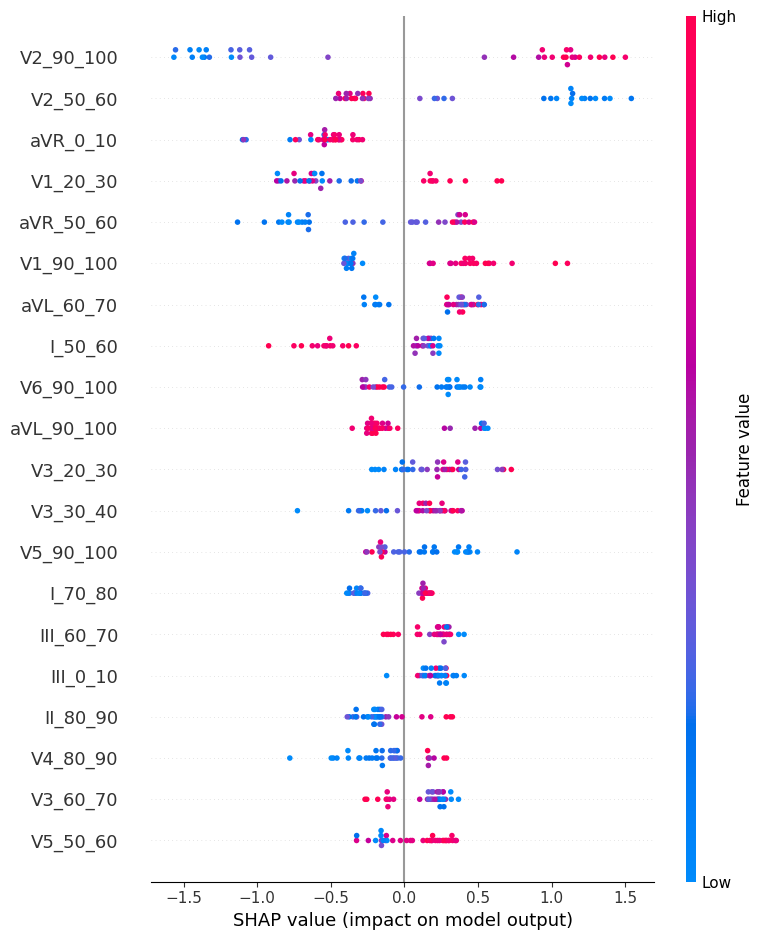

In [19]:
# SHAP beeswarm (tree models only)
base = final_model.steps[-1][1] if isinstance(final_model, Pipeline) else final_model
if SHAP_AVAILABLE and hasattr(base, "feature_importances_"):
    try:
        explainer = shap.TreeExplainer(base)
        sv = explainer.shap_values(X_final_test)
        sv_pos = sv[1] if isinstance(sv, list) else sv
        shap.summary_plot(sv_pos, X_final_test,
                          feature_names=SELECTED_FEATURE_NAMES, show=False)
        plt.tight_layout()
        plt.savefig("fig_exp1_shap_beeswarm.png", dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print(f"SHAP failed: {e!s}")
else:
    print("SHAP skipped (not installed, or final model is not tree-based — for linear "
          "models the coefficients/feature ranking above are themselves the explanation).")

## 8. Summary & artifacts

**Pipeline executed (each decision uses only the training set via CV; the test was touched once):**

1. Representation: 12 × 10 = 120 binned features.
2. Phase A → best dataset combination (by Teknon-validation balanced accuracy).
3. Phase B → best lead subset.
4. Phase C → best classical model.
5. Final model trained on the frozen configuration, evaluated once on the Teknon test (with a
   bootstrap CI because n = 36).
6. Interpretability: lead × bin importance + SHAP, compared against Bocanegra's V2–V4 / R/S
   transition finding.

**Files written**

* `exp1_phaseA_dataset_selection.csv`
* `exp1_phaseB_lead_selection.csv`
* `exp1_phaseC_model_selection.csv`
* `exp1_final_test_results.csv`
* `fig_exp1_final_confusion_roc.png`, `fig_exp1_importance.png`, `fig_exp1_shap_beeswarm.png`

**One line for the slide:** *"Dataset, lead and model selection were performed only on the
training pool via 5-fold cross-validation, reporting both global and Teknon-restricted
validation metrics; the Teknon test set was evaluated exactly once."*

> **Watch-out the professor may probe.** If a combination that includes Teknon in training wins
> Phase A, that is expected (in-domain data helps), but make sure the Teknon-validation metric
> is still measured on Teknon rows that were *not* in that fold's training portion — which the
> helper guarantees, because the validation split is never filtered.
